# Strategy Backtesting

In this notebook, we simulate the historical performance of the volatility-based trading strategy.

Objectives:
1. Evaluate portfolio growth over time
2. Compare strategy performance against benchmark returns
3. Analyze drawdowns and capital preservation
4. Examine trade behavior under different volatility regimes

Backtesting allows us to assess whether the volatility-aware framework would have been effective historically.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
sp500 = pd.read_csv(
    "../data/SP500_processed.csv",
    index_col="Date",
    parse_dates=True
)

In [3]:
sp500["rolling_vol"] = (
    sp500["log_return"]
    .rolling(30)
    .std()
)

threshold = sp500["rolling_vol"].median()

sp500["signal"] = np.where(
    sp500["rolling_vol"] < threshold,
    1,
    0
)

In [4]:
sp500["strategy_return"] = (
    sp500["signal"].shift(1)
    * sp500["log_return"]
)

In [5]:
initial_capital = 100

sp500["portfolio_value"] = (
    initial_capital
    * (1 + sp500["strategy_return"]).cumprod()
)

sp500["market_value"] = (
    initial_capital
    * (1 + sp500["log_return"]).cumprod()
)

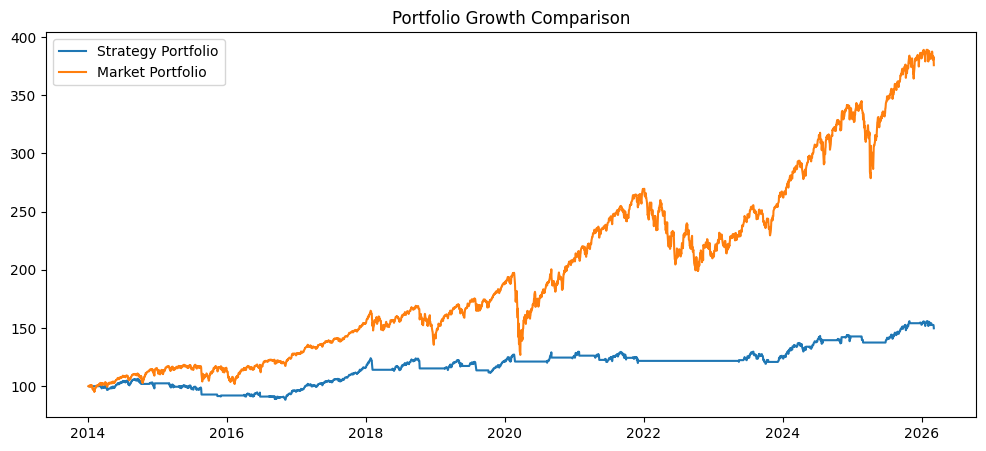

In [6]:
plt.figure(figsize=(12,5))

plt.plot(
    sp500["portfolio_value"],
    label="Strategy Portfolio"
)

plt.plot(
    sp500["market_value"],
    label="Market Portfolio"
)

plt.legend()

plt.title("Portfolio Growth Comparison")

plt.show()

## Portfolio Growth Interpretation

The strategy dynamically adjusts exposure during volatile periods.

This may reduce downside losses during crises while maintaining participation during stable market conditions.

In [7]:
strategy_total_return = (
    sp500["portfolio_value"].iloc[-1]
    / initial_capital
    - 1
)

market_total_return = (
    sp500["market_value"].iloc[-1]
    / initial_capital
    - 1
)

print("Strategy Return:", strategy_total_return)
print("Market Return:", market_total_return)

Strategy Return: 0.49748071753777134
Market Return: 2.758268102198365


In [8]:
trade_changes = (
    sp500["signal"]
    .diff()
    .abs()
)

num_trades = trade_changes.sum()

print("Number of Trades:", num_trades)

Number of Trades: 93.0


In [9]:
rolling_peak = (
    sp500["portfolio_value"]
    .cummax()
)

In [10]:
drawdown = (
    sp500["portfolio_value"]
    - rolling_peak
) / rolling_peak

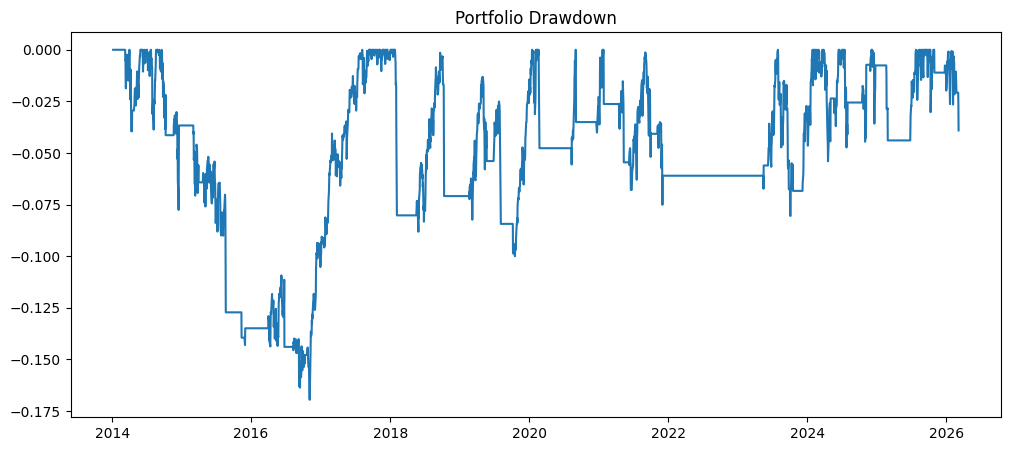

In [11]:
plt.figure(figsize=(12,5))

plt.plot(drawdown)

plt.title("Portfolio Drawdown")

plt.show()

## Drawdown Interpretation

The strategy attempts to preserve capital during periods of elevated volatility.

Reduced drawdowns suggest improved downside protection compared to fully exposed market participation.

# Conclusion

The backtesting framework demonstrates how volatility information can be integrated into practical portfolio management.

By reducing exposure during turbulent periods, the strategy aims to improve risk-adjusted performance and reduce severe drawdowns.

This connects volatility forecasting with real-world trading and investment applications.